In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2  # OpenCV
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from PIL import Image
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from io import BytesIO


In [2]:
dataset_path = r"archive (2)"  
test_image_dir = r"test_data"  


In [4]:
# Dataset paths
dataset_path = r"D:\Masters 1st sem\Introduction to Computer Vision CSC 529\Projects\Final Project\Niyathi_Lekkala_Final_Project\archive (2)"  
test_data_path = r"D:\Masters 1st sem\Introduction to Computer Vision CSC 529\Projects\Final Project\Niyathi_Lekkala_Final_Project\test_data" 

data_gen = ImageDataGenerator(
    rescale=1.0/255.0, 
    validation_split=0.2 
)

# Training Data Generator
train_data = data_gen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training', 
    shuffle=True 
)

# Validation Data Generator
val_data = data_gen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical', 
    subset='validation', 
    shuffle=False  
)

# Test Data Generator
test_data_gen = ImageDataGenerator(rescale=1.0/255.0)  

test_data = test_data_gen.flow_from_directory(
    test_data_path,
    target_size=(128, 128),  
    batch_size=32,
    class_mode='categorical'  
)

Found 34767 images belonging to 38 classes.
Found 8671 images belonging to 38 classes.
Found 10845 images belonging to 38 classes.


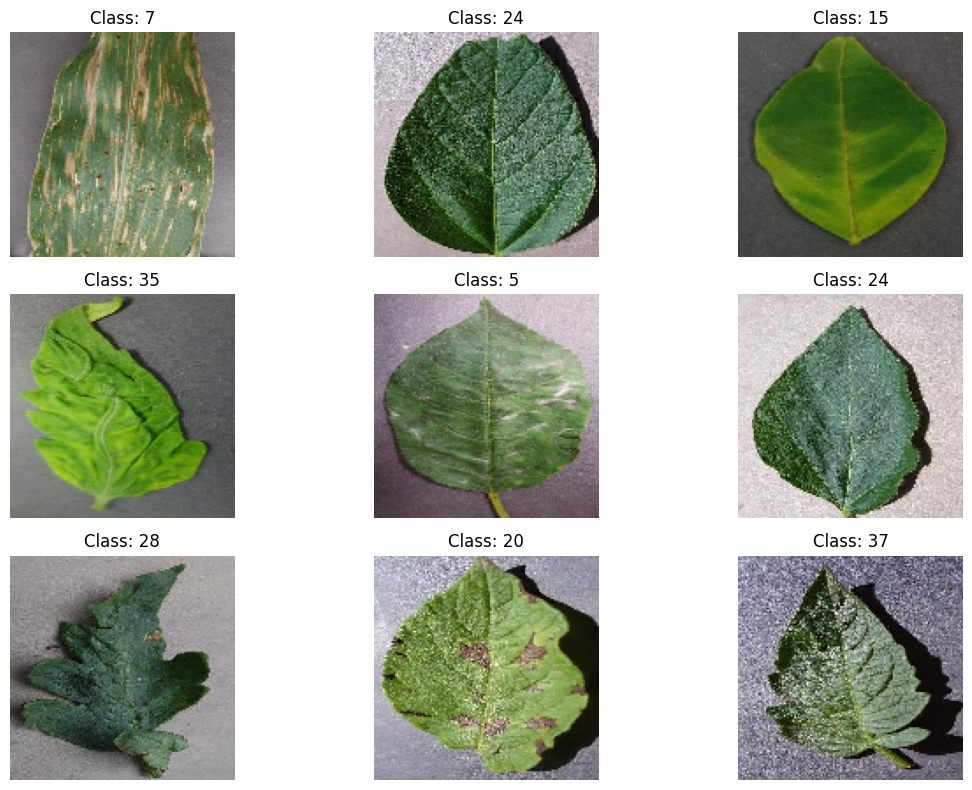

Image saved as 'example_image.jpg'


In [5]:
# Visualize a batch of training images
batch = next(train_data)
images, labels = batch

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title(f"Class: {np.argmax(labels[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Save the first image as an example
image_to_save = (images[0] * 255).astype(np.uint8)
image_to_save = cv2.cvtColor(image_to_save, cv2.COLOR_RGB2BGR)
cv2.imwrite("example_image.jpg", image_to_save)
print("Image saved as 'example_image.jpg'")


In [6]:
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False  

# Build the model
model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax') 
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,621,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,884,454 (18.63 MB)

 Trainable params: 2,626,470 (10.02 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [8]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="keras")

early_stopping = EarlyStopping(
    monitor='val_loss',  
    patience=3,          
    verbose=1,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,  
    callbacks=[early_stopping]
)


Epoch 1/5
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 144s 129ms/step - accuracy: 0.4368 - loss: 2.1740 - val_accuracy: 0.8012 - val_loss: 0.7001
Epoch 2/5
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 136s 125ms/step - accuracy: 0.6114 - loss: 1.2678 - val_accuracy: 0.8541 - val_loss: 0.4874
Epoch 3/5
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 134s 123ms/step - accuracy: 0.6579 - loss: 1.0509 - val_accuracy: 0.8624 - val_loss: 0.4555
Epoch 4/5
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 138s 127ms/step - accuracy: 0.6762 - loss: 0.9759 - val_accuracy: 0.8678 - val_loss: 0.4383
Epoch 5/5
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 138s 127ms/step - accuracy: 0.6930 - loss: 0.9361 - val_accuracy: 0.8697 - val_loss: 0.4218
Restoring model weights from the end of the best epoch: 5.


In [10]:
loss, accuracy = model.evaluate(train_data)
print(f"Training Loss: {loss}")
print(f"Training Accuracy: {accuracy}")

1087/1087 ━━━━━━━━━━━━━━━━━━━━ 108s 99ms/step - accuracy: 0.9011 - loss: 0.3179
Training Loss: 0.32137641310691833
Training Accuracy: 0.9005953669548035


In [11]:
val_loss, val_accuracy = model.evaluate(val_data)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

271/271 ━━━━━━━━━━━━━━━━━━━━ 29s 105ms/step - accuracy: 0.8565 - loss: 0.4733
Validation Loss: 0.42180579900741577
Validation Accuracy: 0.8696805238723755


In [12]:
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


339/339 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - accuracy: 0.8690 - loss: 0.4314
Test Loss: 0.42830127477645874
Test Accuracy: 0.8704472184181213


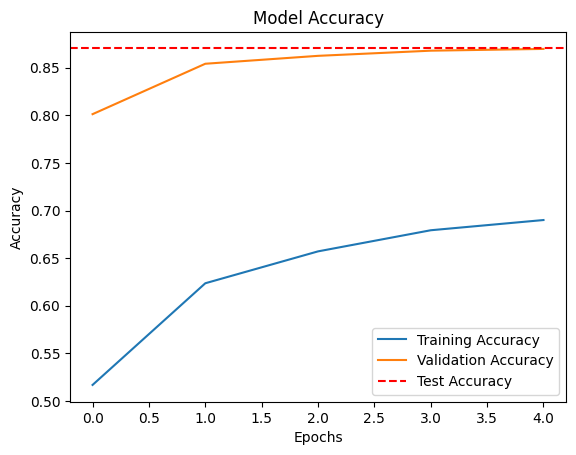

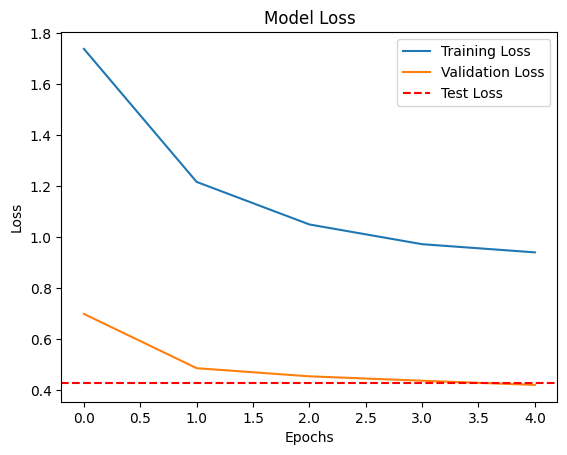

In [16]:
# Plot training ,validation and testing accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.axhline(y=test_accuracy, color='r', linestyle='--', label='Test Accuracy')  
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Plot training, validation and testing loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.axhline(y=test_loss, color='r', linestyle='--', label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.show()


In [17]:
model.save("crop_health_model.keras")
print("Model saved as 'crop_health_model.keras'")

Model saved as 'crop_health_model.keras'


In [18]:
for class_name, count in train_data.class_indices.items():
    print(f"{class_name}: {count}")


Apple___Apple_scab: 0
Apple___Black_rot: 1
Apple___Cedar_apple_rust: 2
Apple___healthy: 3
Blueberry___healthy: 4
Cherry_(including_sour)___Powdery_mildew: 5
Cherry_(including_sour)___healthy: 6
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 7
Corn_(maize)___Common_rust_: 8
Corn_(maize)___Northern_Leaf_Blight: 9
Corn_(maize)___healthy: 10
Grape___Black_rot: 11
Grape___Esca_(Black_Measles): 12
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 13
Grape___healthy: 14
Orange___Haunglongbing_(Citrus_greening): 15
Peach___Bacterial_spot: 16
Peach___healthy: 17
Pepper,_bell___Bacterial_spot: 18
Pepper,_bell___healthy: 19
Potato___Early_blight: 20
Potato___Late_blight: 21
Potato___healthy: 22
Raspberry___healthy: 23
Soybean___healthy: 24
Squash___Powdery_mildew: 25
Strawberry___Leaf_scorch: 26
Strawberry___healthy: 27
Tomato___Bacterial_spot: 28
Tomato___Early_blight: 29
Tomato___Late_blight: 30
Tomato___Leaf_Mold: 31
Tomato___Septoria_leaf_spot: 32
Tomato___Spider_mites Two-spotted_spider_mite:

In [19]:
test_image_dir = r"test_data"
saved_model = load_model("crop_health_model.h5", compile=False)

class_labels = list(train_data.class_indices.keys())  # Replace 'train_data' with your class label source

supported_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

CONFIDENCE_THRESHOLD = 0.5
top_n = 3 

for root, dirs, files in os.walk(test_image_dir):
    for img_file in files:
        if img_file.endswith(supported_extensions):
            img_path = os.path.join(root, img_file)
            try:
                # Preprocess the image
                image = load_img(img_path, target_size=(128, 128))
                image_array = img_to_array(image) / 255.0
                image_array = np.expand_dims(image_array, axis=0)

                # Predict
                prediction = saved_model.predict(image_array)[0]

                # Get top predictions
                top_indices = np.argsort(prediction)[::-1][:top_n]
                top_classes = [class_labels[i] for i in top_indices]
                top_confidences = [prediction[i] for i in top_indices]

                # Print predictions
                print(f"Image: {img_file}")
                for idx, (cls, conf) in enumerate(zip(top_classes, top_confidences)):
                    print(f"  {idx + 1}. {cls}: {conf:.4f}")
                print("-" * 50)

                # Visualize predictions
                title = "\n".join([f"{cls}: {conf:.2f}" for cls, conf in zip(top_classes, top_confidences)])
                plt.imshow(load_img(img_path))  # Show the image
                plt.title(title)
                plt.axis('off')
                plt.show()

            except Exception as e:
                print(f"Error with {img_file}: {e}")


271/271 ━━━━━━━━━━━━━━━━━━━━ 24s 86ms/step


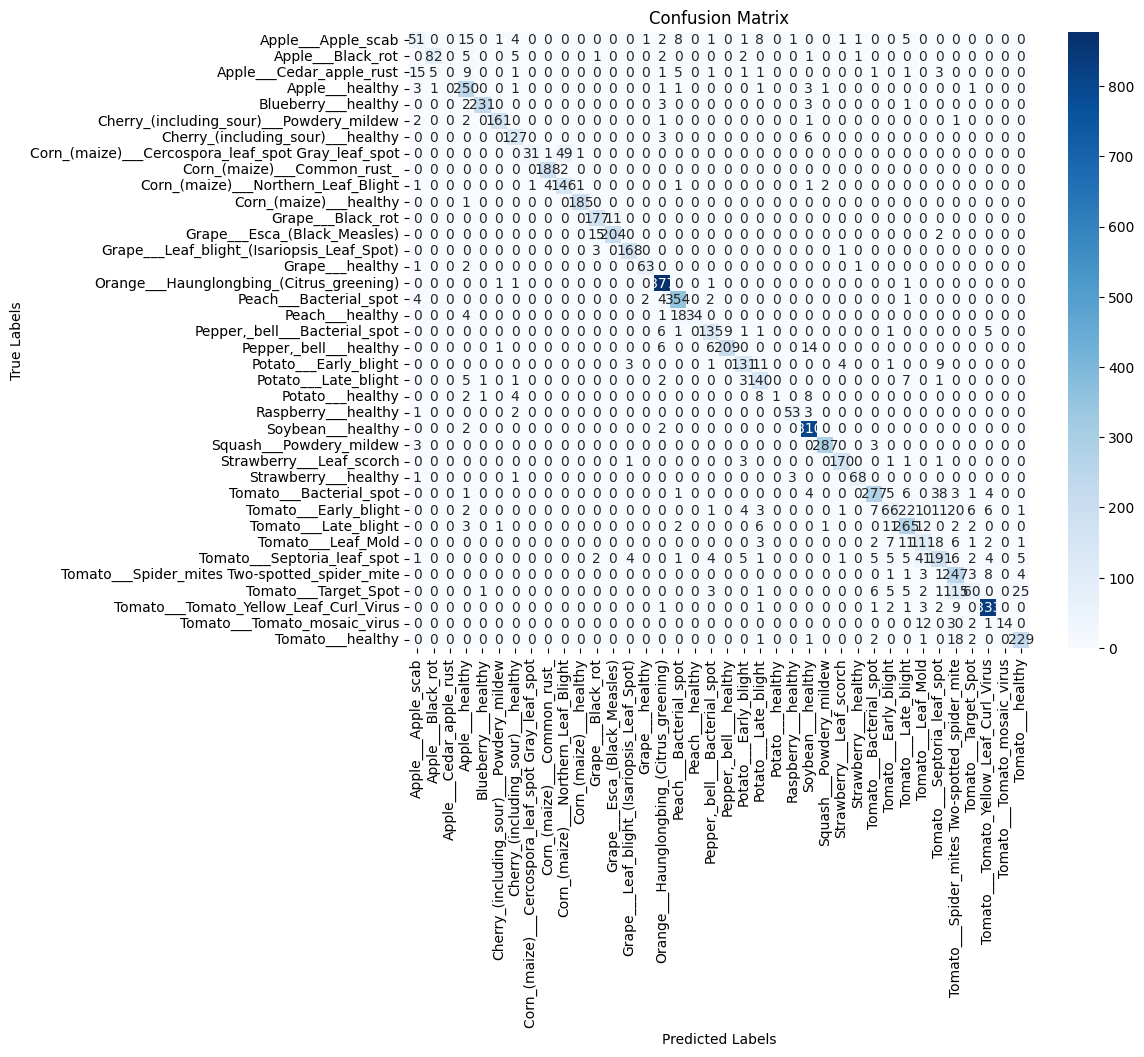

In [20]:
true_classes = val_data.classes  
predictions = saved_model.predict(val_data)
predicted_classes = np.argmax(predictions, axis=1)

conf_matrix = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


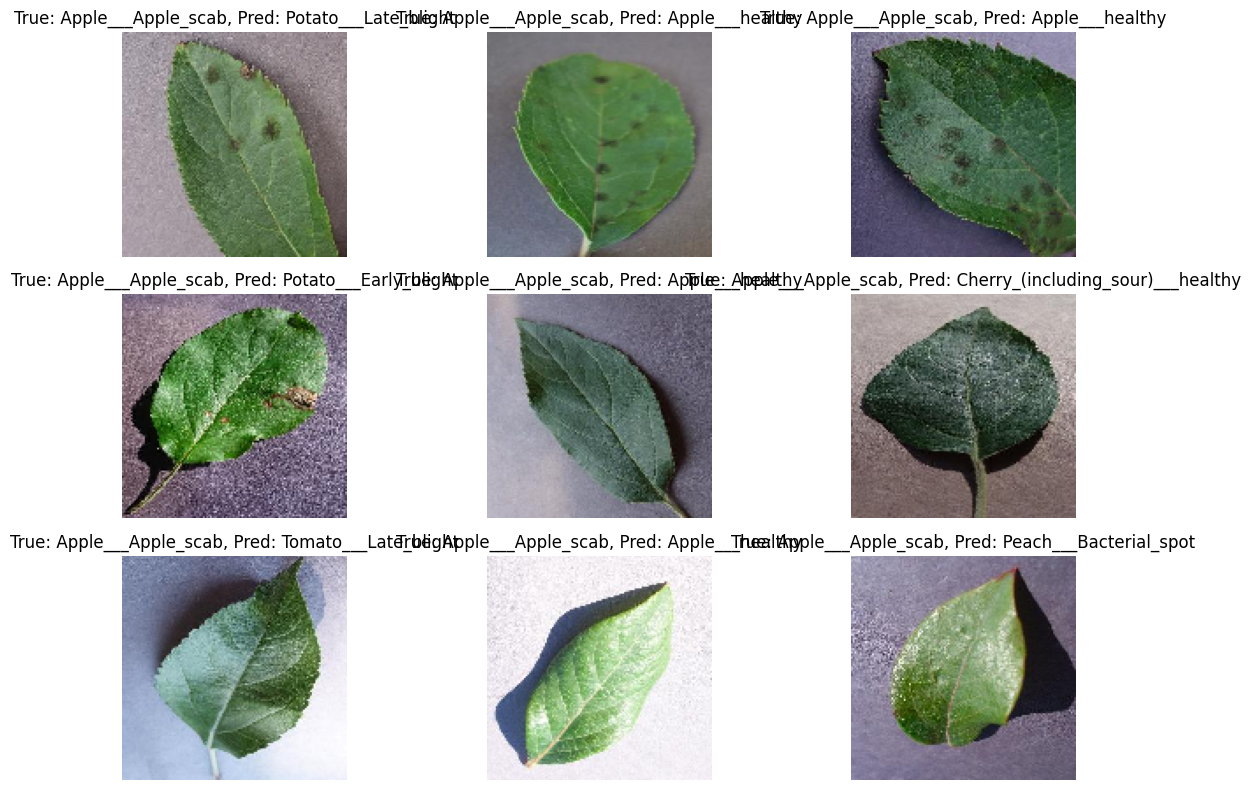

In [62]:
misclassified_indices = np.where(predicted_classes != true_classes)[0]

plt.figure(figsize=(12, 8))
for i, idx in enumerate(misclassified_indices[:9]):
    plt.subplot(3, 3, i+1)
    img, label = val_data[idx]
    plt.imshow(img[0])
    plt.title(f"True: {class_labels[true_classes[idx]]}, Pred: {class_labels[predicted_classes[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [63]:
print("Class Distribution:")
for class_name, count in train_data.class_indices.items():
    print(f"{class_name}: {count}")


Class Distribution:
Apple___Apple_scab: 0
Apple___Black_rot: 1
Apple___Cedar_apple_rust: 2
Apple___healthy: 3
Blueberry___healthy: 4
Cherry_(including_sour)___Powdery_mildew: 5
Cherry_(including_sour)___healthy: 6
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 7
Corn_(maize)___Common_rust_: 8
Corn_(maize)___Northern_Leaf_Blight: 9
Corn_(maize)___healthy: 10
Grape___Black_rot: 11
Grape___Esca_(Black_Measles): 12
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 13
Grape___healthy: 14
Orange___Haunglongbing_(Citrus_greening): 15
Peach___Bacterial_spot: 16
Peach___healthy: 17
Pepper,_bell___Bacterial_spot: 18
Pepper,_bell___healthy: 19
Potato___Early_blight: 20
Potato___Late_blight: 21
Potato___healthy: 22
Raspberry___healthy: 23
Soybean___healthy: 24
Squash___Powdery_mildew: 25
Strawberry___Leaf_scorch: 26
Strawberry___healthy: 27
Tomato___Bacterial_spot: 28
Tomato___Early_blight: 29
Tomato___Late_blight: 30
Tomato___Leaf_Mold: 31
Tomato___Septoria_leaf_spot: 32
Tomato___Spider_mites Two-

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Image from LOCAL: strawberry__Leaf_scorch.jpg


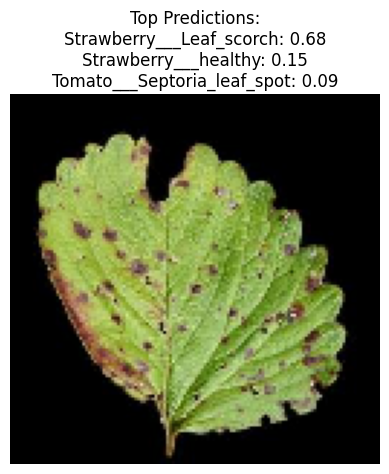

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Image from LOCAL: Potato__late_blight.jpg


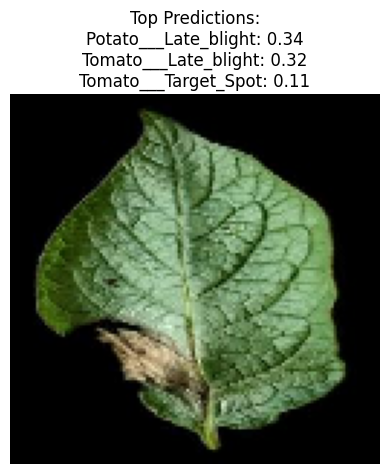

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Image from LOCAL: Raspberry_healthy.jpg


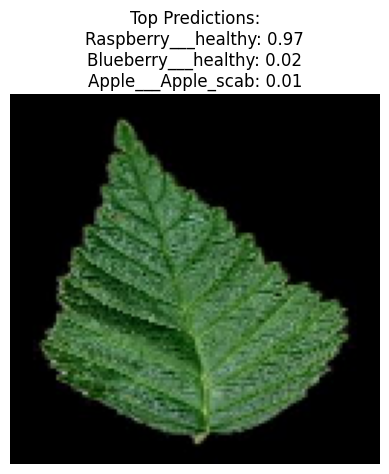

In [60]:
saved_model = load_model("crop_health_model.h5", compile=False)
class_labels = list(train_data.class_indices.keys())

# Supported image extensions
supported_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

def predict_multiple_images(image_paths=None, top_n=3):

    images = []

    if image_paths:
        images.extend([(path, "local") for path in image_paths])

    for image_data, source in images:
        try:
            # Load the image
            if source == "local":
                image = load_img(image_data, target_size=(128, 128)) 
            elif source == "url":
                response = requests.get(image_data)
                image = Image.open(BytesIO(response.content)).convert("RGB")
                image = image.resize((128, 128)) 
            # Preprocess the image
            image_array = img_to_array(image) / 255.0 
            image_array = np.expand_dims(image_array, axis=0)  
            # Predict class probabilities
            prediction = saved_model.predict(image_array)[0]

            # Get top N predictions
            top_indices = np.argsort(prediction)[::-1][:top_n]
            top_classes = [class_labels[i] for i in top_indices]
            top_confidences = [prediction[i] for i in top_indices]

            # Prepare the title with top N predictions
            title = "Top Predictions:\n" + "\n".join([f"{cls}: {conf:.2f}" for cls, conf in zip(top_classes, top_confidences)])

            # Visualize the image and predictions
            print(f"Image from {source.upper()}: {image_data}")
            plt.imshow(image)
            plt.title(title)
            plt.axis('off')
            plt.show()

        except Exception as e:
            print(f"Error processing the image from {source.upper()}: {image_data} | Error: {e}")

image_paths = [
    r"strawberry__Leaf_scorch.jpg",
    r"Potato__late_blight.jpg",
    r"Raspberry_healthy.jpg"
]

predict_multiple_images(image_paths=image_paths, top_n=3)
